In [6]:
# pip install lazypredict
# !pip install seaborn

### Código para Classificação (LazyClassifier) com suporte ROC AUC em multiclasses

A ROC AUC (Área Sob a Curva ROC) é uma métrica usada para avaliar modelos de classificação, particularmente em problemas binários. É baseada na Curva ROC (Receiver Operating Characteristic), que é um gráfico que mostra a relação entre:

Taxa de verdadeiros positivos (True Positive Rate - TPR): Proporção de instâncias positivas corretamente classificadas.

Taxa de falsos positivos (False Positive Rate - FPR): Proporção de instâncias negativas incorretamente classificadas como positivas.

O valor AUC (Área Under the Curve) mede a área sob essa curva. Ele varia de 0 a 1:

1.0: O modelo é perfeito.

0.5: O modelo não tem capacidade discriminativa (equivalente a um chute aleatório).

< 0.5: O modelo é pior que um chute aleatório.

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier

# Carregar os dados do arquivo
file_path = '../../sensor_data GY-87_1.txt'
df = pd.read_csv(file_path, header=None, names=['x', 'y', 'z'])

# Usar apenas os primeiros 50 mil dados
df = df.iloc[:50000]

# Extrair apenas o eixo Z
z = df['z']

# Criar labels para classificação
df['z_class'] = pd.qcut(z, q=5, labels=[0, 1, 2, 3, 4])

# Definir as features (X) e o target (y)
X = df[['z']]  # Feature: eixo Z
y = df['z_class']  # Target: classes baseadas na magnitude de Z

# Dividir os dados em conjunto de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Inicializar o LazyClassifier
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)

# Ajustar o classificador e obter os melhores modelos
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

# Exibir os resultados do LazyClassifier
print("Modelos avaliados com LazyClassifier:")
print(models)

# Selecionar o melhor modelo identificado (exemplo: LGBMClassifier)
best_model = LGBMClassifier(objective='multiclass', num_class=5, random_state=123, verbosity=-1)
best_model.fit(X_train, y_train)

# Obter as probabilidades previstas para o conjunto de teste
y_pred_proba = best_model.predict_proba(X_test)

# Binarizar os rótulos reais (necessário para o cálculo do ROC AUC)
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2, 3, 4])

# Calcular o ROC AUC usando as médias micro e macro
roc_auc_micro = roc_auc_score(y_test_binarized, y_pred_proba, average='micro', multi_class='ovr')
roc_auc_macro = roc_auc_score(y_test_binarized, y_pred_proba, average='macro', multi_class='ovr')

# Exibir os resultados do ROC AUC
print(f"\nROC AUC (Micro): {roc_auc_micro}")
print(f"ROC AUC (Macro): {roc_auc_macro}")



100%|██████████| 31/31 [03:33<00:00,  6.87s/it]


Modelos avaliados com LazyClassifier:
                               Accuracy  Balanced Accuracy ROC AUC  F1 Score  \
Model                                                                          
LGBMClassifier                     1.00               1.00    None      1.00   
SVC                                1.00               1.00    None      1.00   
BaggingClassifier                  1.00               1.00    None      1.00   
ExtraTreesClassifier               1.00               1.00    None      1.00   
ExtraTreeClassifier                1.00               1.00    None      1.00   
KNeighborsClassifier               1.00               1.00    None      1.00   
DecisionTreeClassifier             1.00               1.00    None      1.00   
XGBClassifier                      1.00               1.00    None      1.00   
RandomForestClassifier             1.00               1.00    None      1.00   
GaussianNB                         0.99               0.99    None      0.99   
Qu

In [8]:
# Verificar a contagem de cada classe
print(df['z_class'].value_counts())

z_class
0    10129
3    10009
2    10003
1     9967
4     9892
Name: count, dtype: int64


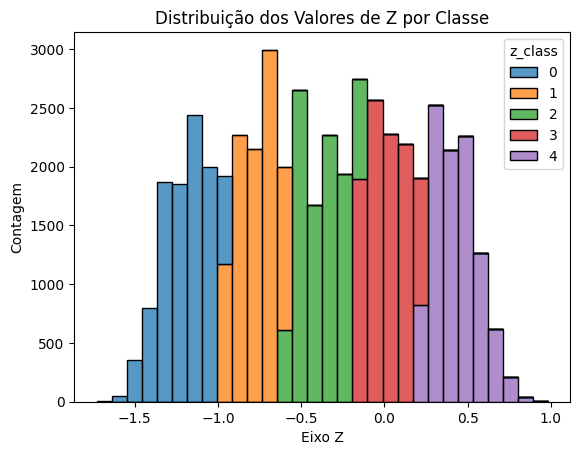

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data=df, x='z', hue='z_class', multiple='stack', bins=30)
plt.xlabel('Eixo Z')
plt.ylabel('Contagem')
plt.title('Distribuição dos Valores de Z por Classe')
plt.show()


### Código para Regressão (LazyRegressor)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyRegressor

# Carregar os dados do arquivo
file_path = '../../sensor_data GY-87_1.txt'
df = pd.read_csv(file_path, header=None, names=['x', 'y', 'z'])

# Usar apenas os primeiros 50 mil dados
df = df.iloc[:50000]

# Extrair apenas o eixo Z
z = df['z']

# Definir as features (X) e o target (y) para regressão
X = df[['z']]  # Usando apenas o eixo Z como feature
y = z  # O target é o próprio eixo Z, como regressão contínua

# Dividir os dados em conjunto de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Inicializar o LazyRegressor
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)

# Ajustar o regressor e obter os melhores modelos
models, predictions = reg.fit(X_train, X_test, y_train, y_test)

# Exibir os resultados dos modelos
print(models)


100%|██████████| 42/42 [10:55<00:00, 15.61s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 229
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 1
[LightGBM] [Info] Start training from score -0.381253
                               Adjusted R-Squared  R-Squared  RMSE  Time Taken
Model                                                                         
Lars                                         1.00       1.00  0.00        0.01
HuberRegressor                               1.00       1.00  0.00        0.19
OrthogonalMatchingPursuit                    1.00       1.00  0.00        0.01
LinearSVR                                    1.00       1.00  0.00        0.01
LinearRegression                             1.00       1.00  0.00        0.01
LassoLarsIC                               